In [3]:
%matplotlib inline

import matplotlib as mpl
import numpy as np
import pandas as pd

import plasma_box as pd

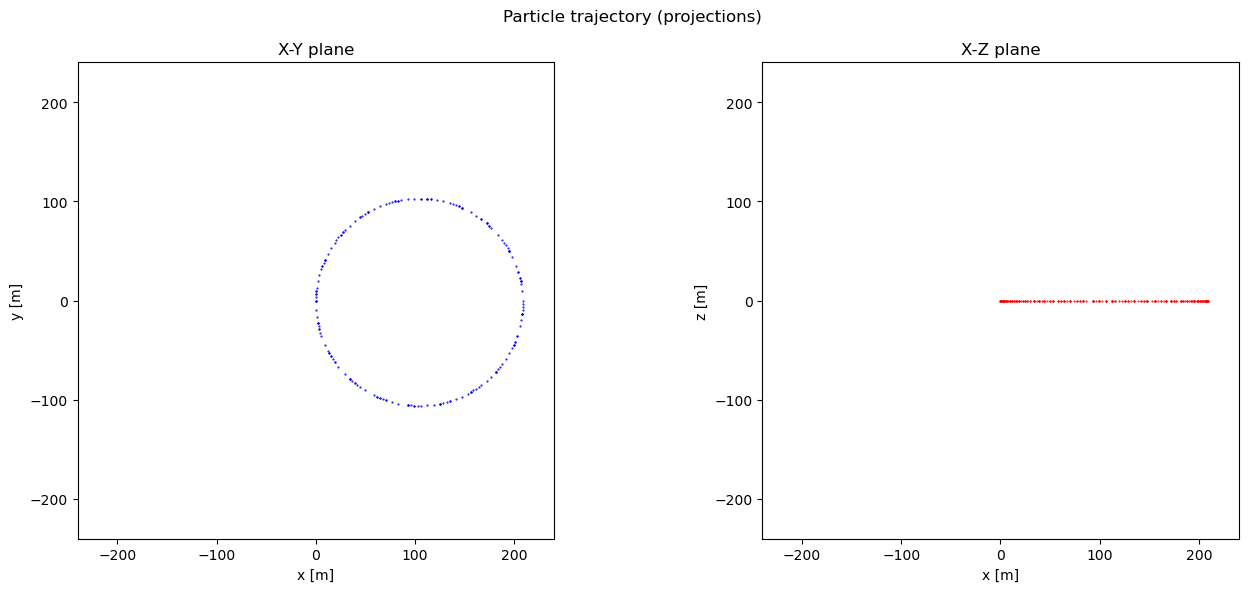

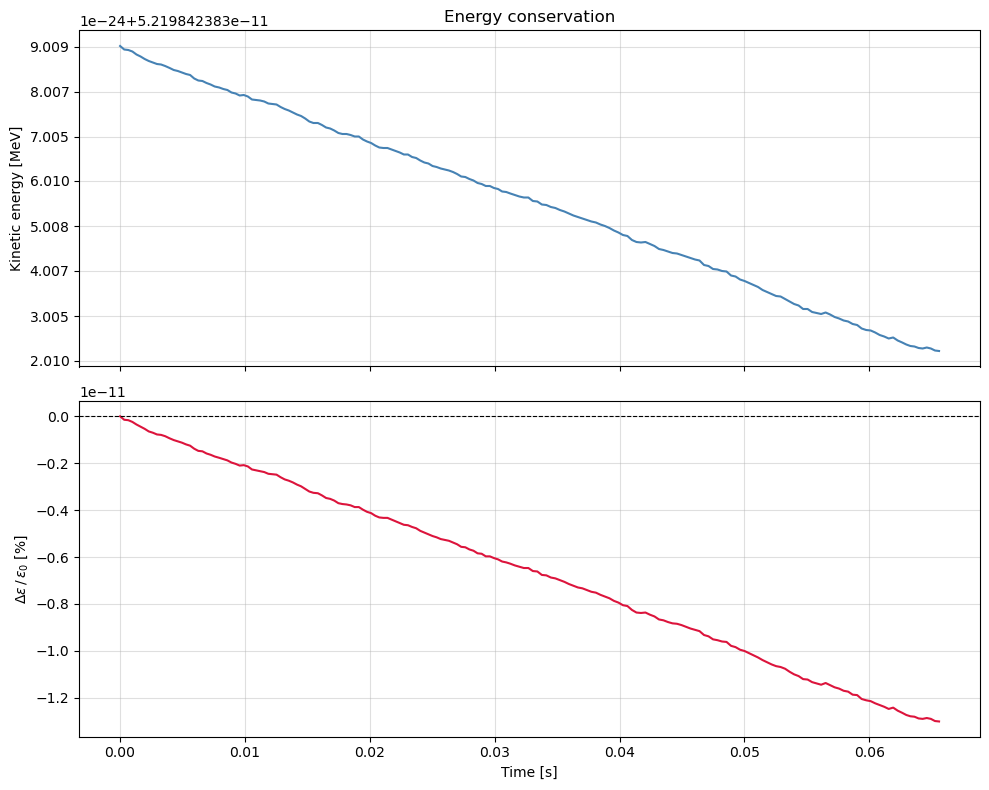

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from plasma_box import (UniformB, single_particle, BorisC,
                        plot_trajectory_2d, plot_energy,
                        gyroperiod, Q_E, M_P)

field = UniformB(B=(0, 0, 1e-5))      # 10 µT along z
Tc = gyroperiod(Q_E, M_P, 1e-5)       # gyro-period in seconds
particle = single_particle(q=Q_E, m=M_P, r0=[0,0,0], v0=[0, 1e5, 0])

sim = BorisC(particle, field, dt=Tc/200, t_max=10*Tc, store_dt=Tc/20)
history = sim.run()

# Trajectory in X-Y and X-Z planes
plot_trajectory_2d(history, length_unit=1.0, unit_label="m")

# Energy conservation check
plot_energy(history, sim.state.m, relativistic=False)
plt.show()

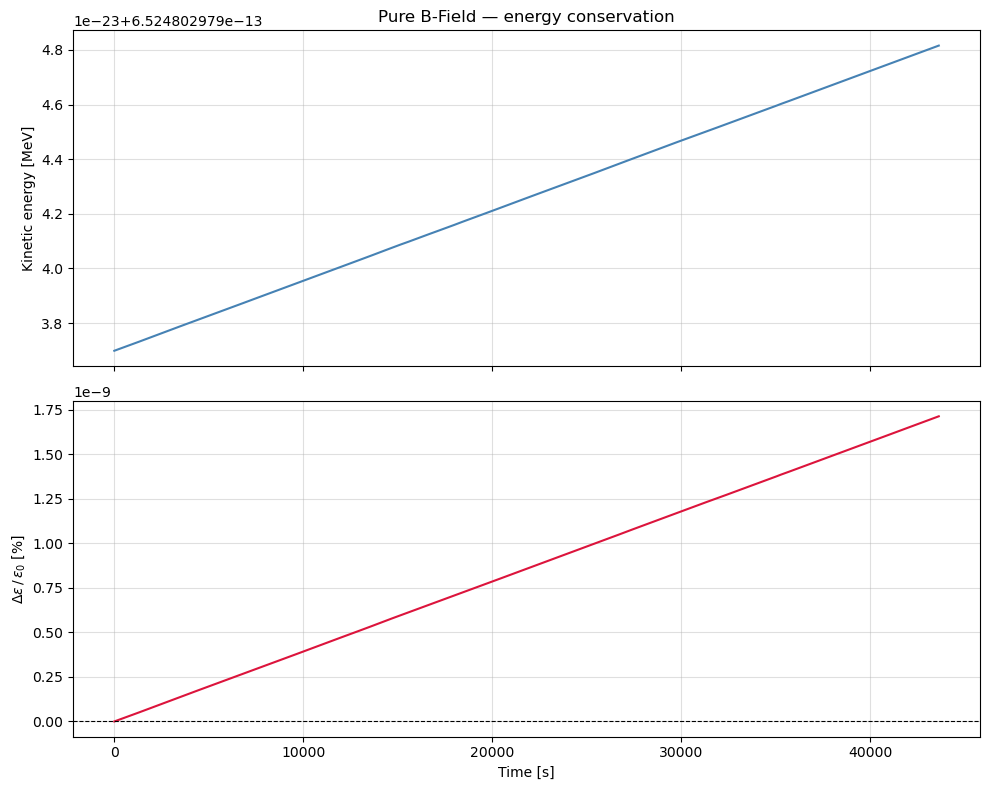

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from plasma_box.constants import C
from plasma_box import (UniformB, single_particle, BorisB,
                        plot_energy, gyroperiod, Q_E, M_P)

# CyclotronWaveField is removed. Replaced with UniformB.
field = UniformB(B=(0, 0, 3e-10))
Tc = gyroperiod(Q_E, M_P, 3e-10)

particle = single_particle(q=Q_E, m=M_P, r0=[0,0,0], v0=[0, 1e4, 5e3])
sim = BorisB(particle, field, dt=Tc/200, t_max=200*Tc, store_dt=Tc)
history = sim.run()

# Energy should remain perfectly constant without an electric wave
plot_energy(history, sim.state.m, relativistic=False,
            title="Pure B-Field — energy conservation")
plt.show()

  t = 1 s  (step 10000)
  t = 2 s  (step 20000)
  t = 3 s  (step 30000)
  t = 4 s  (step 40000)
  t = 5 s  (step 50000)
  t = 6 s  (step 60000)


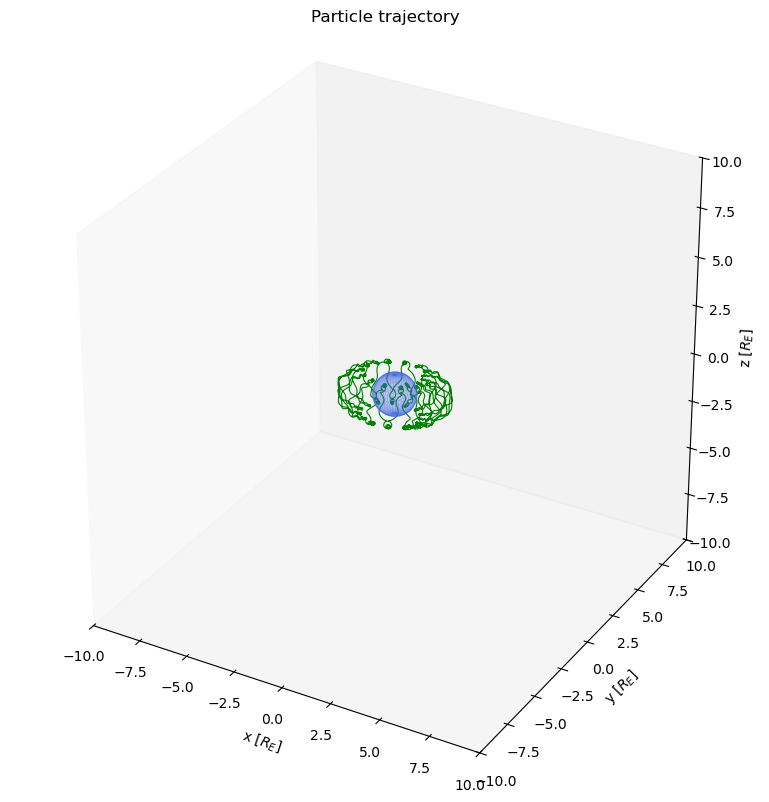

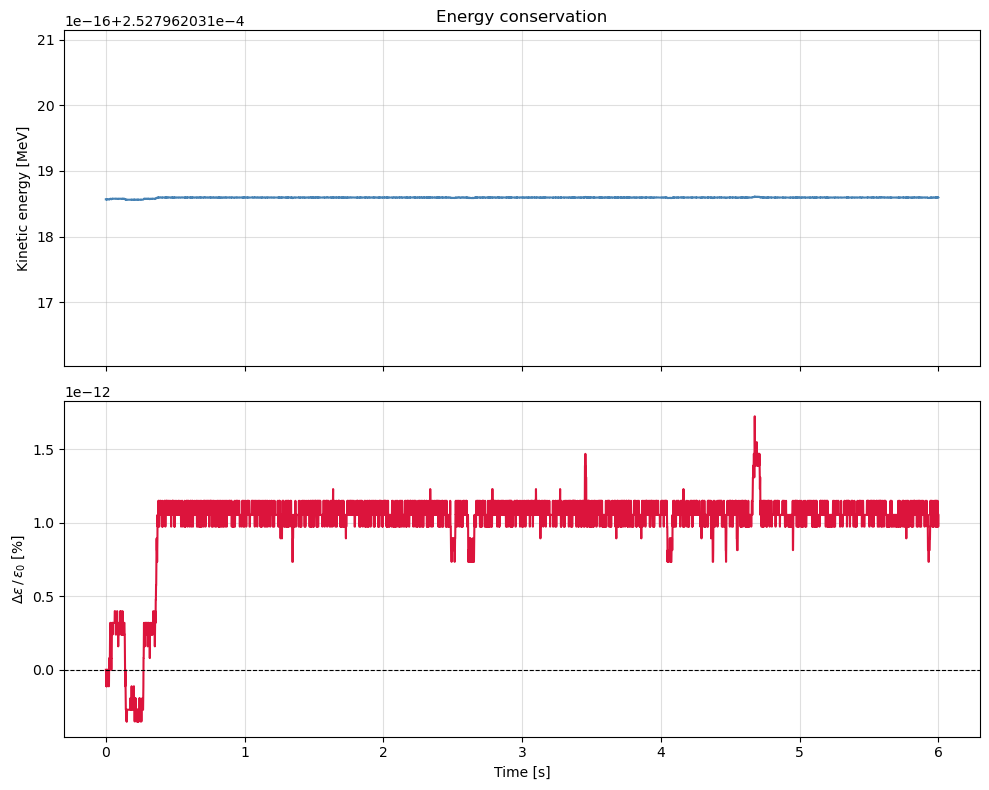

In [15]:
import matplotlib.pyplot as plt
from plasma_box import (EarthDipole, BorisC, dipole_initial_conditions,
                        plot_trajectory_3d, plot_energy, R_EARTH)

field = EarthDipole()
particle = dipole_initial_conditions()   # proton at 2.5 R_E, ~0.6c
sim = BorisC(particle, field, dt=1e-4, t_max=6.0, store_dt=1e-3)
history = sim.run(progress_every=10_000)

# 3D orbit with wireframe Earth sphere
plot_trajectory_3d(history, length_unit=R_EARTH, unit_label=r"$R_E$",
                   earth_sphere=True, ax_lim=10)

# Energy conservation — Boris-C should hold it very tight
plot_energy(history, sim.state.m, relativistic=True)
plt.show()

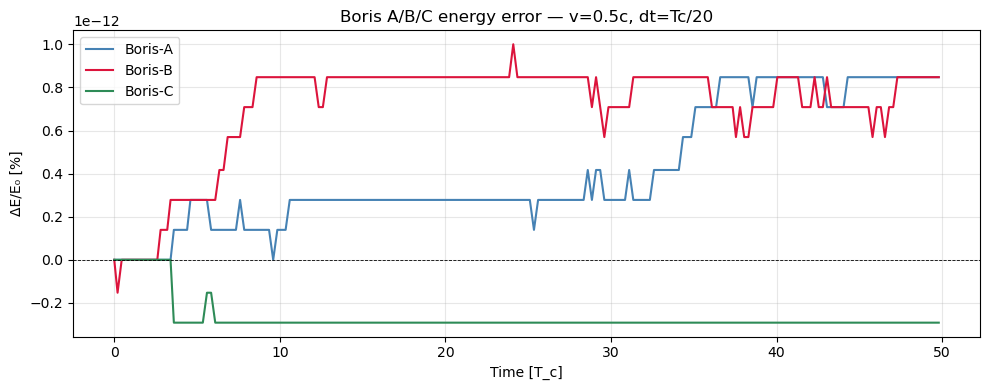

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from plasma_box import (UniformB, single_particle, BorisA, BorisB, BorisC,
                        relative_energy_error, gyroperiod, Q_E, M_P, C)

field = UniformB(B=(0, 0, 3e-10))
Tc = gyroperiod(Q_E, M_P, 3e-10)

# Relativistic particle — differences between A/B/C are more visible
particle = single_particle(q=Q_E, m=M_P, r0=[0,0,0], v0=[0, 0.5*C, 0])
dt = Tc/20   # deliberately coarse to show the phase-error difference

fig, ax = plt.subplots(figsize=(10, 4))
for cls, label, color in [(BorisA, "Boris-A", "steelblue"),
                          (BorisB, "Boris-B", "crimson"),
                          (BorisC, "Boris-C", "seagreen")]:
    sim = cls(particle.copy(), field, dt=dt, t_max=50*Tc,
              store_dt=Tc/5, relativistic=True)
    h = sim.run()
    err = relative_energy_error(h, sim.state.m, relativistic=True)[:,0] * 100
    ax.plot(h.t/Tc, err, label=label, color=color)

ax.set_xlabel("Time [T_c]")
ax.set_ylabel("ΔE/E₀ [%]")
ax.set_title("Boris A/B/C energy error — v=0.5c, dt=Tc/20")
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

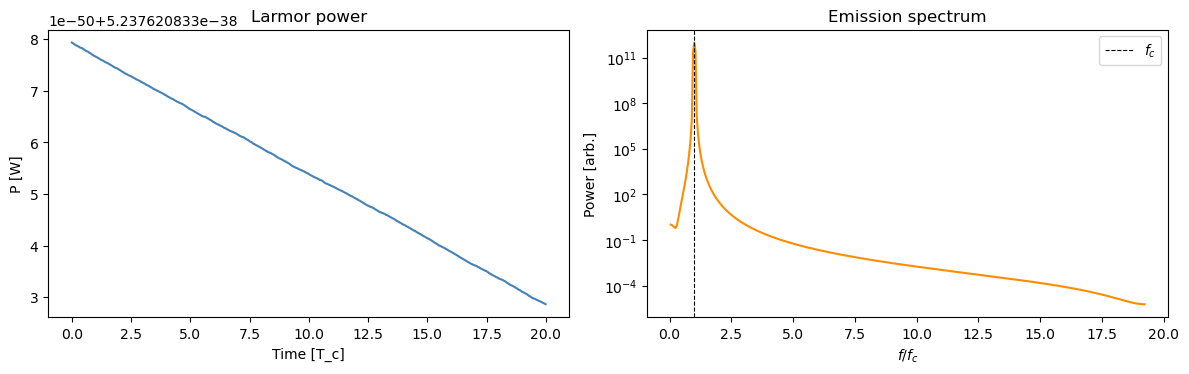

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from plasma_box import (UniformB, single_particle, BorisC,
                        gyroperiod, Q_E, M_P)
from plasma_box.radiation import radiated_power, spectrum_fft

field = UniformB(B=(0, 0, 1e-5))
Tc = gyroperiod(Q_E, M_P, 1e-5)

# Need store_dt << Tc so FFT can resolve the gyrofrequency
particle = single_particle(q=Q_E, m=M_P, r0=[0,0,0], v0=[0, 1e5, 0])
sim = BorisC(particle, field, dt=Tc/500, t_max=20*Tc, store_dt=Tc/40)
h = sim.run()

# Instantaneous radiated power over time
P = radiated_power(h, sim.state.q, sim.state.m, field, relativistic=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(h.t/Tc, P[:,0], color='steelblue')
ax1.set_xlabel("Time [T_c]")
ax1.set_ylabel("P [W]")
ax1.set_title("Larmor power")

# Frequency spectrum — peak should be at the cyclotron frequency
freqs, power = spectrum_fft(h, pid=0)
f_c = 1.0 / Tc

ax2.semilogy(freqs/f_c, power, color='darkorange')
ax2.axvline(1.0, color='k', lw=0.8, ls='--', label=r'$f_c$')
ax2.set_xlabel(r"$f / f_c$")
ax2.set_ylabel("Power [arb.]")
ax2.set_title("Emission spectrum")
ax2.legend()
plt.tight_layout()
plt.show()

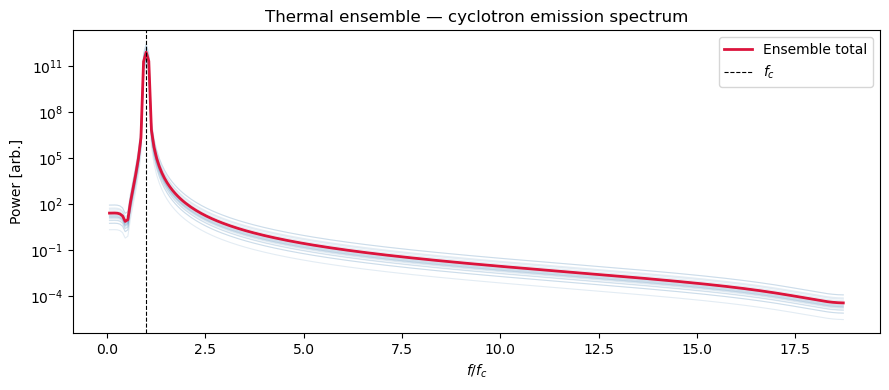

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from plasma_box import (UniformB, maxwellian_ensemble, BorisC,
                        gyroperiod, Q_E, M_P)
from plasma_box.radiation import ensemble_spectrum

field = UniformB(B=(0, 0, 1e-5))
Tc = gyroperiod(Q_E, M_P, 1e-5)

# 20 protons from a 10^6 K Maxwell-Boltzmann distribution
particles = maxwellian_ensemble(N=20, T=1e6, m=M_P, seed=42)
sim = BorisC(particles, field, dt=Tc/300, t_max=15*Tc, store_dt=Tc/40)
h = sim.run()

# Total spectrum = incoherent sum of all 20 particles
freqs, total, individual = ensemble_spectrum(h, method='fft')
f_c = 1 / Tc

fig, ax = plt.subplots(figsize=(9, 4))
for p in individual:
    ax.semilogy(freqs/f_c, p + 1e-40, color='steelblue', alpha=0.15, lw=0.8)

ax.semilogy(freqs/f_c, total + 1e-40, color='crimson', lw=2, label='Ensemble total')
ax.axvline(1.0, color='k', lw=0.8, ls='--', label=r'$f_c$')
ax.set_xlabel(r"$f/f_c$")
ax.set_ylabel("Power [arb.]")
ax.set_title("Thermal ensemble — cyclotron emission spectrum")
ax.legend()
plt.tight_layout()
plt.show()

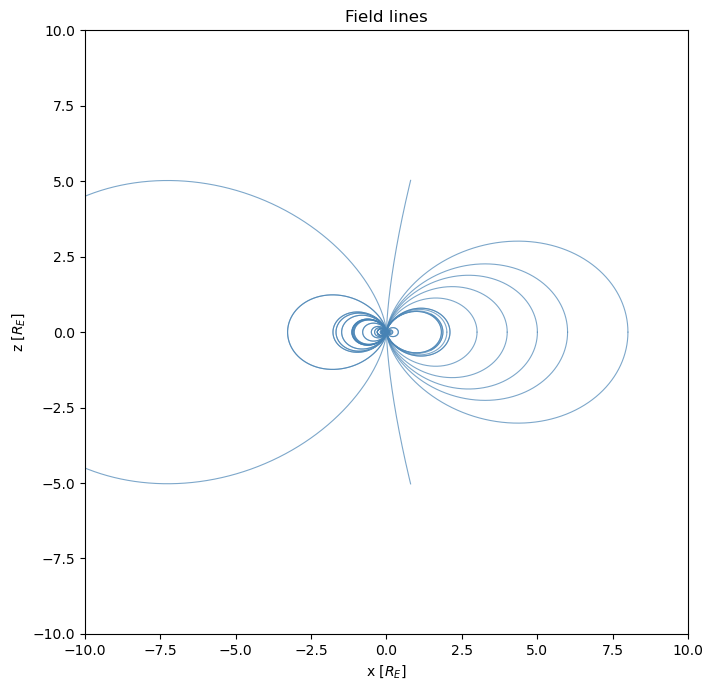

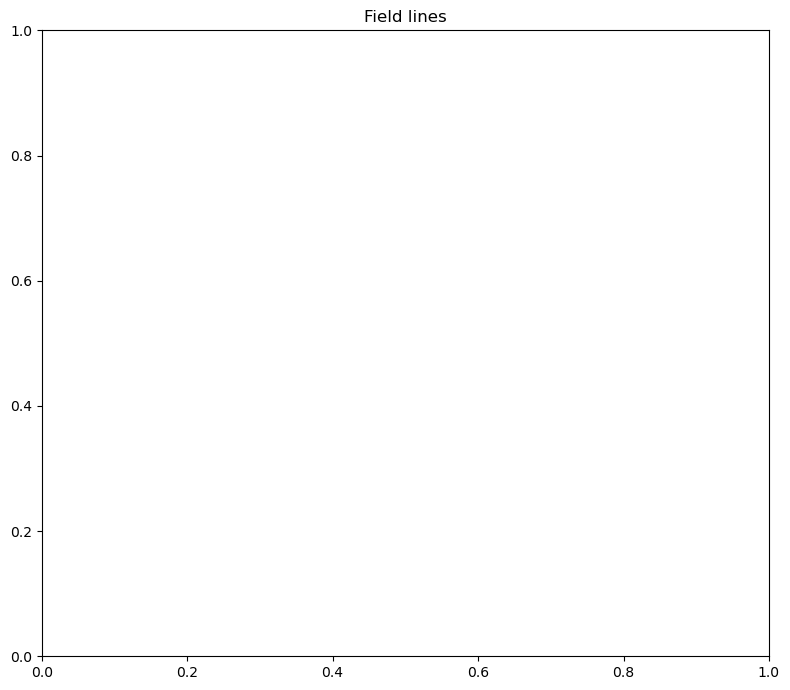

In [21]:
import matplotlib.pyplot as plt
from plasma_box import EarthDipole, UniformB, R_EARTH
from plasma_box.fieldlines import plot_field_lines

field = EarthDipole()

# Classic L-shell dipole field lines in the X-Z (meridional) plane
fig, ax = plot_field_lines(
    field,
    components=("B",),
    seed_strategy="dipole_Lshells",   # L = 2,3,4,5,6,8 R_E
    density="medium",
    r_max=12*R_EARTH,
    length_unit=R_EARTH, unit_label=r"$R_E$",
    projection="xz",
    earth_sphere=False,
    ax_lim=10,
)
plt.show()

# UniformEB is removed. Replaced with UniformB pure magnetic test.
field2 = UniformB()
fig2, ax2 = plot_field_lines(
    field2,
    components=("B",),
    density="low",
    r_max=1e6,
    projection="xy",
)
plt.show()

In [22]:
import matplotlib.pyplot as plt
from plasma_box import (EarthDipole, BorisC, dipole_initial_conditions, R_EARTH)
from plasma_box.animation import plot_overview, make_overview_gif, make_panel_gif

field = EarthDipole()
particle = dipole_initial_conditions()
sim = BorisC(particle, field, dt=1e-4, t_max=6.0, store_dt=1e-3)
history = sim.run()

# Static 6-panel summary figure
fig = plot_overview(
    history, field,
    q=sim.state.q, m=sim.state.m,
    length_unit=R_EARTH, unit_label=r"$R_E$",
    field_components=("B",),     # Explicitly request B lines only
    spectrum_method="fft",
)
plt.savefig("overview.png", dpi=120)

# Animated GIF of the full overview (all 6 panels evolving together)
make_overview_gif(
    history, field,
    q=sim.state.q, m=sim.state.m,
    filename="overview.gif",
    fps=20, n_frames=150,
    length_unit=R_EARTH, unit_label=r"$R_E$",
    field_components=("B",),
    spectrum_method="fft",
    spectrum_update_every=8,   # FFT panel refreshes every 8th GIF frame
)

# Just the position trajectory as a standalone GIF
make_panel_gif(
    history, "position_xy",
    field=field, q=sim.state.q, m=sim.state.m,
    filename="trajectory.gif",
    fps=20, n_frames=150,
    length_unit=R_EARTH, unit_label=r"$R_E$",
)

/home/fritz/work/notebooks/MASS/Plasma/plasma_box/animation.py:166: UserWarning: r_max is not set. Field-line traces stop only at max_steps. Set r_max to avoid incomplete or very long traces.
  plot_field_lines(


Saved: overview.gif
Saved: trajectory.gif


'trajectory.gif'

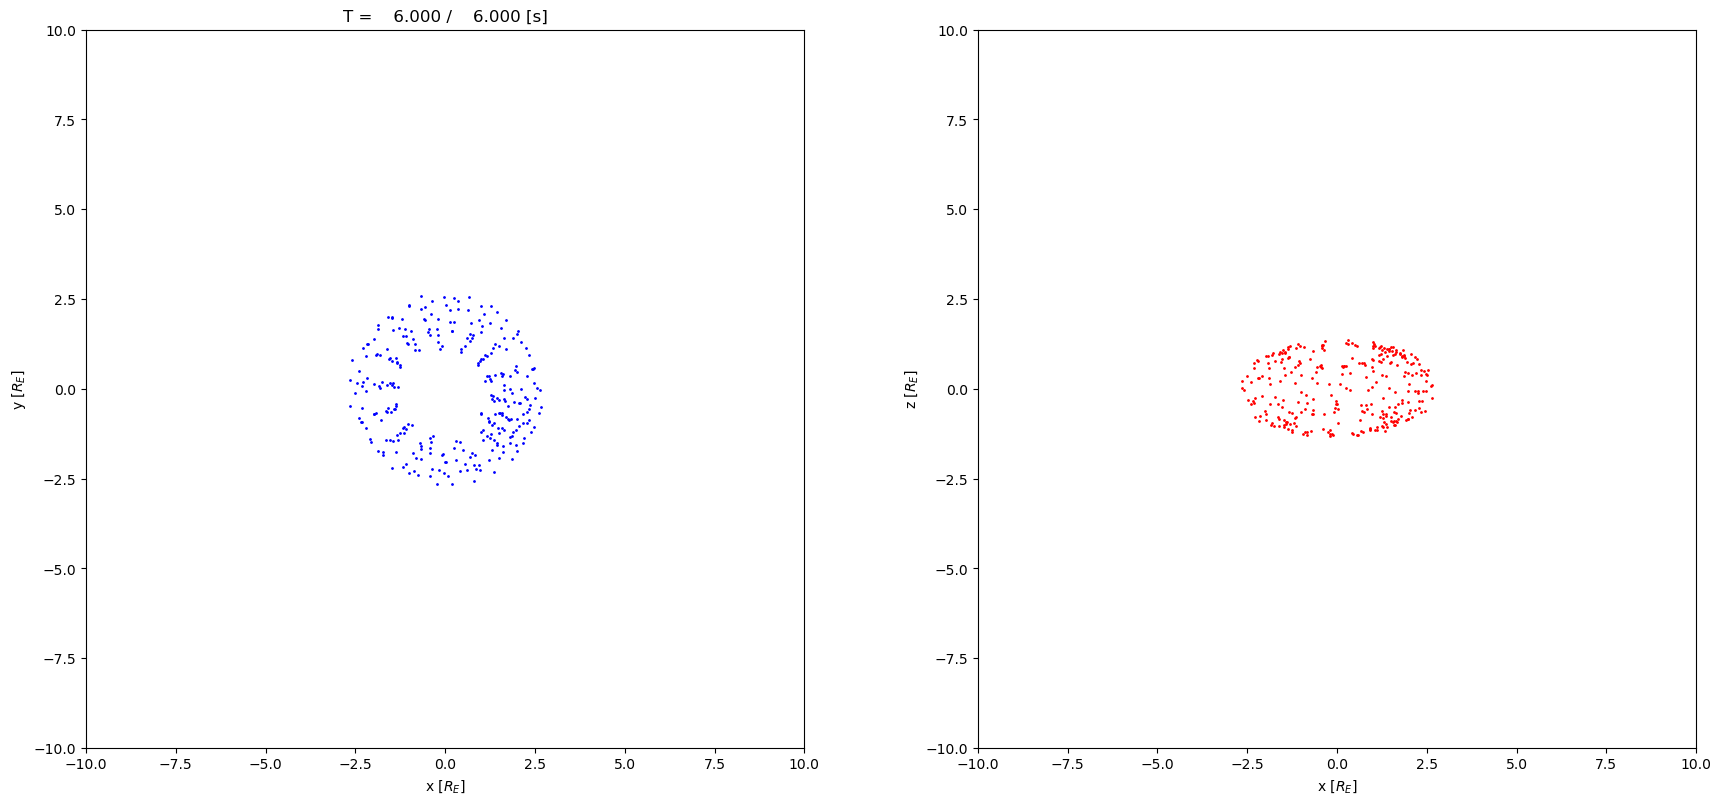

In [23]:
from plasma_box import EarthDipole, BorisC, dipole_initial_conditions, R_EARTH
from plasma_box.plotting import LivePlotter

field = EarthDipole()
particle = dipole_initial_conditions()
sim = BorisC(particle, field, dt=1e-4, t_max=6.0, store_dt=1e-3)

# LivePlotter auto-detects whether you're in Jupyter and uses
# IPython.display.clear_output there, or plt.pause in a script
live = LivePlotter(ax_lim=10.0, length_unit=R_EARTH, unit_label=r"$R_E$")
history = sim.run(live_plotter=live, live_every=200)
live.close()